<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


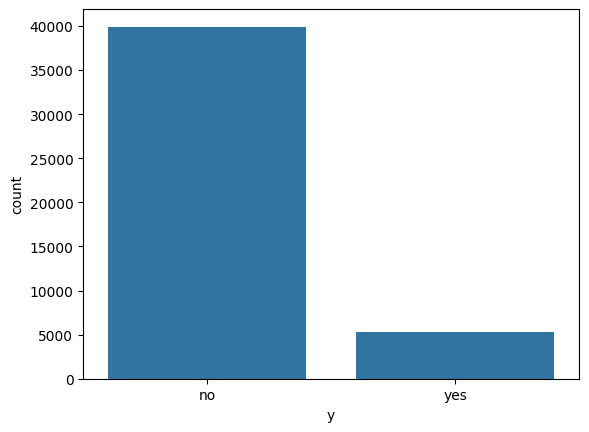

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')
df = pd.read_csv("C:\\Users\\YASHWITHA\\OneDrive\\Desktop\\bank-marketing-project\\data\\bank.csv", sep=';' )
df.head()
df.shape
df.columns
df.info()
df.describe()
df['y'].value_counts()
sns.countplot(x='y', data=df)
plt.show()

In [2]:
#missing values
df.isnull().sum()
for col in df.columns:
    print(col, df[col].value_counts().head())

age age
32    2085
31    1996
33    1972
34    1930
35    1894
Name: count, dtype: int64
job job
blue-collar    9732
management     9458
technician     7597
admin.         5171
services       4154
Name: count, dtype: int64
marital marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default default
no     44396
yes      815
Name: count, dtype: int64
balance balance
0    3514
1     195
2     156
4     139
3     134
Name: count, dtype: int64
housing housing
yes    25130
no     20081
Name: count, dtype: int64
loan loan
no     37967
yes     7244
Name: count, dtype: int64
contact contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
day day
20    2752
18    2308
21    2026
17    1939
6     1932
Name: count, dtype: int64
month month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
Name

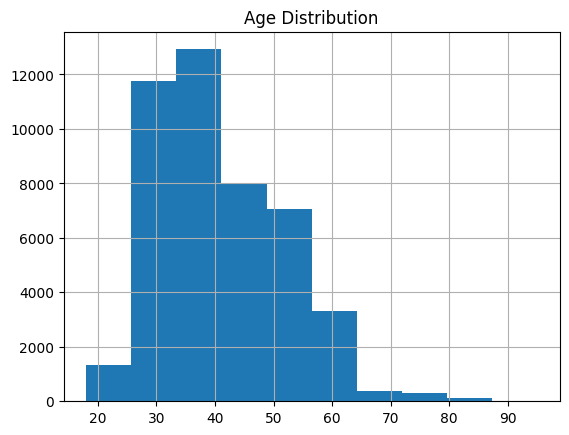

In [3]:
#univariate single columns
df['age'].hist()
plt.title("Age Distribution")
plt.show()

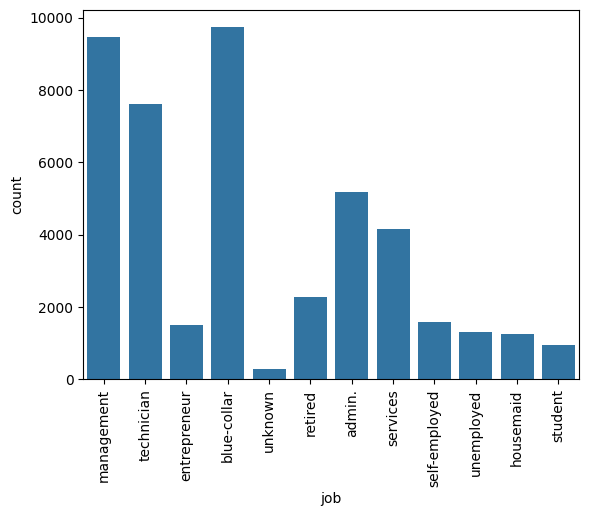

In [4]:
#categorical features
sns.countplot(x='job', data=df)
plt.xticks(rotation=90)
plt.show()

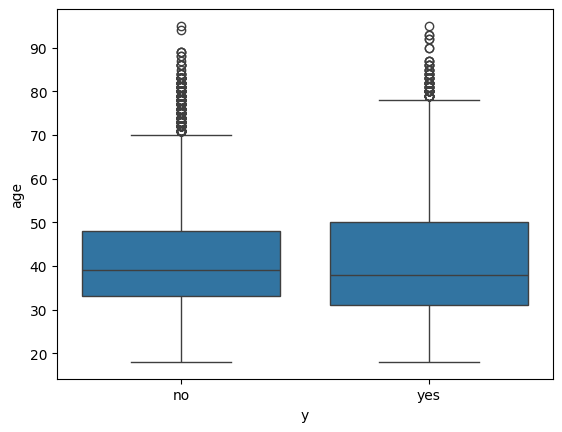

In [5]:
#bivariate
sns.boxplot(x='y', y='age', data=df)
plt.show()

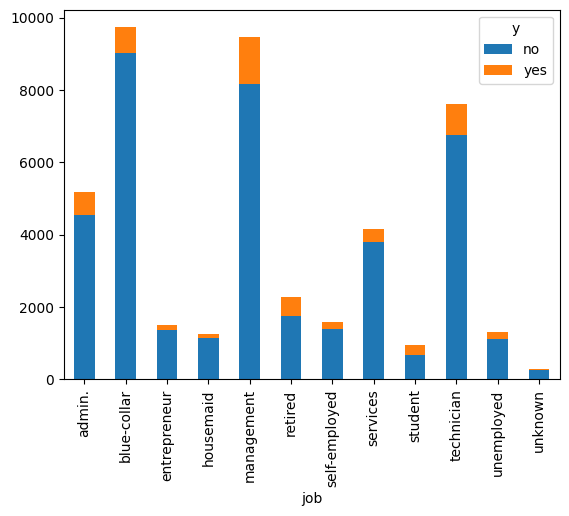

In [6]:
#jo vs subscription
pd.crosstab(df['job'], df['y']).plot(kind='bar', stacked=True)
plt.show()

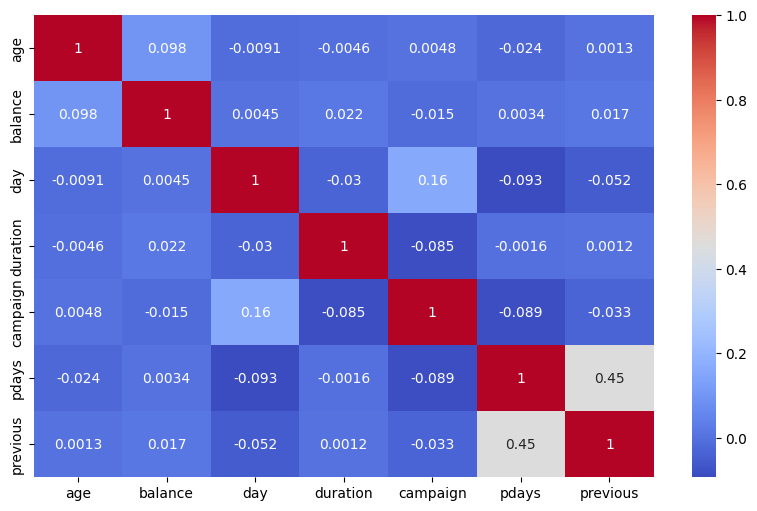

In [7]:
#corelation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [8]:
#data cleaning
for col in df.columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])


In [9]:
for col in df.columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])
df['y'] = df['y'].map({'yes': 1, 'no': 0})
#encode categorical variable
df = pd.get_dummies(df, drop_first=True)

#feature selection
df = df.drop('duration', axis=1)
X = df.drop('y', axis=1)
y = df['y']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

#evaluate
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.8910759703638174
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.66      0.20      0.30      1091

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.86      9043



In [10]:
class_weight='balanced'
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    params,
    scoring='f1',
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
from sklearn.utils import resample

df_majority = df[df.y == 0]
df_minority = df[df.y == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)


{'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 50}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.3).astype(int)
print(classification_report(y_test, y_pred))
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_prob
})

results.to_csv("C:\\Users\\YASHWITHA\\OneDrive\\Desktop\\bank-marketing-project\\outputs\\predictions.csv", index=False)
import pickle

pickle.dump(rf, open('../models/model.pkl', 'wb'))
importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))


[[7844  108]
 [ 858  233]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.68      0.21      0.33      1091

    accuracy                           0.89      9043
   macro avg       0.79      0.60      0.63      9043
weighted avg       0.88      0.89      0.87      9043

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7952
           1       0.49      0.38      0.43      1091

    accuracy                           0.88      9043
   macro avg       0.70      0.66      0.68      9043
weighted avg       0.87      0.88      0.87      9043

balance                0.177806
age                    0.156647
day                    0.136950
campaign               0.071843
pdays                  0.049391
poutcome_success       0.037208
housing_yes            0.032641
previous               0.027411
month_may              0.019133
education_secondary    0.018166

In [12]:
from src.preprocessing import load_data, clean_data, encode_data, split_data

df = load_data('../data/bank.csv')
df = clean_data(df)
df = encode_data(df)

X, y = split_data(df)

print(X.shape)
print(y.shape)

(45211, 38)
(45211,)


In [13]:
!python ../src/train.py

Model Evaluation:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.69      0.22      0.33      1091

    accuracy                           0.89      9043
   macro avg       0.80      0.60      0.64      9043
weighted avg       0.88      0.89      0.87      9043

Model saved successfully!


In [14]:
from src.preprocessing import load_data, clean_data, encode_data, split_data
from src.predict import predict

df = load_data('../data/bank.csv')
df = clean_data(df)
df = encode_data(df)

X, y = split_data(df)

# Test on sample
sample = X.iloc[:5]

pred, prob = predict(sample)

for i in range(len(sample)):
    print(f"Customer {i}:")
    print(f"Prediction: {'Will Purchase' if pred[i]==1 else 'Will Not Purchase'}")
    print(f"Confidence: {prob[i]:.2f}")
    print()

Customer 0:
Prediction: Will Not Purchase
Confidence: 0.05

Customer 1:
Prediction: Will Not Purchase
Confidence: 0.01

Customer 2:
Prediction: Will Not Purchase
Confidence: 0.01

Customer 3:
Prediction: Will Not Purchase
Confidence: 0.01

Customer 4:
Prediction: Will Not Purchase
Confidence: 0.00



In [15]:
y_prob = rf.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7952
           1       0.49      0.38      0.43      1091

    accuracy                           0.88      9043
   macro avg       0.70      0.66      0.68      9043
weighted avg       0.87      0.88      0.87      9043



In [16]:
import os
os.makedirs('../outputs', exist_ok=True)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_prob
})

results.to_csv('../outputs/predictions.csv', index=False)

In [17]:
sample = X.iloc[100:120]

pred, prob = predict(sample)

print(pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [19]:
pred, prob = predict(sample, threshold=0.2)

In [20]:
sample = X.iloc[:100]

pred, prob = predict(sample, threshold=0.2)

print("Number of YES predictions:", sum(pred))

Number of YES predictions: 2


In [21]:
pred, prob = predict(sample, threshold=0.1)
print("YES predictions:", sum(pred))

YES predictions: 4


In [22]:
!python ../src/train.py

Model Evaluation:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.69      0.22      0.33      1091

    accuracy                           0.89      9043
   macro avg       0.80      0.60      0.64      9043
weighted avg       0.88      0.89      0.87      9043

Model saved successfully!


In [23]:
!python ../src/train.py

Model Evaluation:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      7952
           1       0.38      0.56      0.45      1091

    accuracy                           0.84      9043
   macro avg       0.66      0.72      0.68      9043
weighted avg       0.87      0.84      0.85      9043

Model saved successfully!


In [24]:
pred, prob = predict(sample, threshold=0.05)
print("YES predictions:", sum(pred))

YES predictions: 10


In [25]:
sample = X.iloc[:200]
pred, prob = predict(sample, threshold=0.05)

print("YES predictions:", sum(pred))

YES predictions: 30


In [27]:
from sklearn.utils import resample

df_majority = df[df.y == 0]
df_minority = df[df.y == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df = pd.concat([df_majority, df_minority_upsampled])

In [28]:
sample = X.iloc[:200]
pred, prob = predict(sample, threshold=0.05)

print("YES predictions:", sum(pred))

YES predictions: 30


In [29]:
import os
os.makedirs('../outputs', exist_ok=True)

sample = X_test  # use full test set

pred, prob = predict(sample, threshold=0.05)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred,
    'Probability': prob
})

results.to_csv('../outputs/predictions.csv', index=False)

In [ ]:
!streamlit run ../app/app.py

In [ ]:
streamlit run app/app.py

In [ ]:
!streamlit run ../app/app.py

In [ ]:
python src/train.py